# Final Project PART 2: Indexing and Evaluation

In [3]:
import os, sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..', '..')))

from collections import defaultdict, Counter
from dotenv import load_dotenv

from myapp.search import load_corpus as lc
from project_progress.part_1.data_prep import build_terms, join_build_terms

load_dotenv()  # take environment variables from .env

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\auror\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
def corpus_df_loading(path):
    """
    In this function we load the corpus as dataframe, and we preprocess the numerical fields.

    :param path: Path to the json file.
    :return corpus: Returns a dictionary List[Document] with the loaded corpus with the numerical fields preprocessed.
    """
    corpus = lc.load_corpus(path)
    return corpus

In [5]:
json_path = "../../data/fashion_products_dataset.json"
corpus = corpus_df_loading(json_path)

## Indexing

### Inverted Index

The first step of this delivery is to create the **inverted index**. According to the last part of the project, we want to create the index in the following format:

```json
inverted_index =  {
    "term1": {
        "field1": [docID, [pos1, pos2]],
        "field2": [docID, [pos1]],
        ...
    },
    "term2": {
        "field2": [docID, [pos1, pos2]],
        ...
    },
    ...
}
```

Where we have sub indices for each term, where we keep record of where the `term` is found in the document in terms of the `field` ("category", "brand", "title_description", etc.).

Additionally, knowing that we are gonna use a TF-IDF ranking, we are gonna compute and store in the same function `create_index_tf_idf`, the `tf` (term frequency), `df` (document frequency), and `idf` (inverse document frequency) for later computationsa as it is worth it to iterate over the `corpus` only once.

To compute the mentioned metrics, we need to take into account the structure of our index. We constructed it so that we could apply weights to terms in different fields. For instance, give more relevance to a term appearing in the field `category`, than that same term appearing in the field `product_details`. With this goal, we need to compute the TF-IDF in the following way: $$\text{TF-IDF}(t,d)=IDF_t · \sum_{f\in F}{w_f · TF_{t,f,d}^\text{norm}}$$

+ $\text{TF}_{t,f,d}^\text{norm}$: normalized frequency of term $t$ in field $f$ of document $d$
+ $\text{IDF}_t$: computed globally for term $t$
+ $w_f$: the weight assigned to field $f$
+ $F$: set of fields in which term $t$ appears in document $d$

We consider each field in the document as a separate text region with its own frequency behaviour.

Then, to store the `df`, `tf`, and `idf` during the computation of the index, we are gonna create three extra dictionaries:

```python
df = {
    "term1": df1,
    "term2": df2,
    ...
}

idf = {
    "term1": idf1,
    "term2": idf2,
    ...
}

tf = {
    "doc1": {
        "term1": {
        "field1": tf1,
        "field2": tf2,
        ...
        },
        "term2": {
            "field1": tf3,
            ...
        },
        ...
    },
    "doc2": {...},
    ...    
}
```

And then, the computation of the TF-IDF will be as follows:

```python
# Compute the tf per term
tf[term] = 0
for field in list_of_fields:
    tf[term] += weigths[field] * tf[term][field]

# Compute the tf-idf
tf_idf[term] = idf[term] * tf[term]
```

Where we compute for all `term`s in the inverted index, and `tf` should be normalized in the computation of `tf_idf`. But we did not take into account the tf per document (to simplify logic).

The computation of the index and the `tf`, `df`, and `idf` are made in the following function:

In [6]:
def create_index_tf_idf(corpus):
    """
    Implement the inverted index and compute tf, df and idf

    Argument:
    corpus -- list of Documents containing the description of the product

    Returns:
    index - the inverted index (implemented through a Python dictionary) containing terms as keys 
     and the corresponding list of document these keys appears in (and the positions) as values.
    index2title - a mapping of article pid to its title
    tf - normalized term frequency for each term in each document
    df - number of documents each term appear in
    idf - inverse document frequency of each term
    """

    index = defaultdict(dict)
    tf = defaultdict(lambda: defaultdict(dict))
    df = defaultdict(int)
    idf = {}
    index2title = {}
    num_articles = len(corpus)

    for product in list(corpus.values()):
        index2title[product.pid] = product.title
        # For each field to be considered in the index, get its terms
        title_description = join_build_terms(
            [product.title, product.description]
        )  # Pre-process the `title` and `description`
        brand_terms = join_build_terms([product.brand])
        category_terms = join_build_terms([product.category])
        sub_category_terms = join_build_terms([product.sub_category])
        seller_product_details = join_build_terms(
            [
                product.seller,
                " ".join([detail for detail in product.product_details.values()]),
            ]
        )  # Pre-process the `title` and `description`

        # Fields and target terms to process
        fields = [
            "title_description",
            "brand",
            "category",
            "sub_category",
            "seller_product_details",
        ]
        target = [
            title_description,
            brand_terms,
            category_terms,
            sub_category_terms,
            seller_product_details,
        ]

        # Initialize a temporal dictionary to store the index terms for the current article
        current_article_index = defaultdict(dict)

        # Create the index for the current article
        # For each field we consider in the index
        for field_idx, field in enumerate(fields):
            # For each term in the target field
            for position, term in enumerate(target[field_idx]):
                try:
                    # Add the new found term's position to the dict
                    current_article_index[term][field][1].append(position)
                except:
                    # Create the entry for the term and field if it didn't exist
                    current_article_index[term][field] = [product.pid, [position]]

        seen_terms = set()
        for field in fields:
            norm = 0
            for term, postings in current_article_index.items():
                if (
                    field in postings.keys()
                ):  # Check that the term appear in the current field
                    norm += len(postings[field][1]) ** 2
            norm = math.sqrt(norm)

            for term, postings in current_article_index.items():
                if field in postings.keys():
                    pid = postings[field][0]
                    # Compute term frequency and document frequency of each term per category
                    tf[pid][term][field] = np.round(len(postings[field][1]) / norm, 4)

                    # In the practice, the tf/df and the index were in separate loops. Both 
                    # codes are now in one loop to avoid reading the same twice
                    # Join the current article's index with the global index
                    try: # Add the array of positions ("[id, [[0],[1]]]"") in the given term and field
                        index[term][field].append(
                            postings[field]
                        )  
                    except: # Create the entry for the term and the field with the array of positions
                        index[term][field] = [
                            postings[field]
                        ]  

                if term not in seen_terms:
                    df[term] += 1
                    seen_terms.add(term)

    for term in df.keys():
        idf[term] = np.round(np.log(float(num_articles / df[term])), 4)

    return index, index2title, tf, df, idf

In [7]:
index, index2title, tf, df, idf = create_index_tf_idf(corpus=corpus)

### Weights assignment

To know what weights to assign to each field in the document, we started by using the same weight for each term, and then tried looking for what fields seemed to be more important. In the end, the weights we chose are:

In [8]:
weights = {
        "title_description": 1.0,
        "brand": 0.5,
        "category": 0.3,
        "sub_category": 0.4,
        "seller_product_details": 0.2,
    } 

It is left as a future work to use some techniques to decide (not empirically) the best configuration of these weights. For instance, using:
+ With a relevance evaluated data, create several candidate weights and measure performance. Obtain the best configuration optimizing them (e.g. with GridSearch as seen in class).
+ Feautre Importance with Learning to rank. Treat each field's TF-IDF as a feature and train a lightweight model to learn effective relative weights.

### Queries selection

As hinted in the statement, we will use the ranking on `tf` to see the each term's frequency and know which words to choose from each query. First we compute the ranking based on tf and then we select queries both with very common terms, and also including some not that common words. Our idea was to select different kinds of terms such as: clothes, materials, occasion terms, adjectives, etc.

NOTE: the tf is normalized.

In [9]:
# Compute the ranking on tf terms
overall_tf = defaultdict(float)

# As we computed the tf dependent on fields, we need to put all of them together (adding them)
list_tf = list(tf.items())
for doc, doc_tf in list_tf:
    for term, freq in doc_tf.items():
        overall_tf[term] += sum(float(v) for v in freq.values())

overall_tf = dict(overall_tf)

sorted_tf = dict(sorted(overall_tf.items(), key=lambda x: x[1], reverse=True))

for term, total in sorted_tf.items():
    print(f"{term:15} -> {total:.3f}")

cloth           -> 20801.618
accessori       -> 20489.974
topwear         -> 15310.490
neck            -> 7992.599
wear            -> 6392.516
cotton          -> 5983.263
women           -> 5720.502
men             -> 5621.230
round           -> 5588.518
solid           -> 5133.891
print           -> 5050.661
1               -> 4882.042
regular         -> 4652.134
sleev           -> 4637.967
wash            -> 4388.736
shirt           -> 3817.614
bottomwear      -> 3672.289
western         -> 3441.874
blend           -> 3011.922
machin          -> 2975.271
fit             -> 2713.045
black           -> 2700.837
blue            -> 2632.673
casual          -> 2444.519
india           -> 2399.398
slim            -> 2249.191
full            -> 2201.013
polo            -> 1979.192
winter          -> 1908.200
footwear        -> 1861.156
fabric          -> 1646.244
half            -> 1630.918
multicolor      -> 1482.033
2               -> 1461.472
white           -> 1453.865
short           -

In [10]:
queries = ["western leather jacket men",                # context, material, specific cloth, gender
           "cotton innerwear man",                      # material, specific cloth, gender
           "yellow black t-shirt women xl",             # adjectives, specific cloth, gender, size
           "casual comfortable blue trousers women",    # context, adjectives, specific cloth, gender
           "breathable sports clothes winter"]          # adjectives, context, general clothes, context

### Ranking

To implement the ranking, we based the functions in the Practice Session 1 code. We created a `rank_tf_idf` function that generates the ranking given some documents and the inverted index. But the ranking is not done for all documents in the corpus. First, we have a `filter` function that given the corpus and a query, it selects only the documents that contain ALL query terms:

In [11]:
def filter(query, index):
    """
    The output is the list of documents that contain ALL query terms.

    :param query: (string) query
    :param index: (Dict) inverted index dictinary
    :return selected_docs: (List) of documents' ids that contain all query terms
    """

    query_terms = build_terms(query)
    docs = None
    for term in query_terms:
        try:
            # Get all doc ids from the term
            all_doc_ids = [
                doc_id
                for categories in index[term].values()
                for doc_id, _ in categories
            ]

            # Get intersection of documents with ALL the terms
            if docs is None:  # First time, set is empty
                docs = set(all_doc_ids)  # Initiallize with first term's doc ids
            else:
                docs &= set(all_doc_ids)

        except:
            pass

    return query_terms, list(docs)

In [33]:
def rank_tf_idf(query_terms, products, index, tf, idf, weights):
    """
    Perform the ranking of the results of a search based on the tf-idf weights

    Argument:
    terms -- list of query terms
    products -- list of products to rank that match the query
    index -- inverted index data structure
    tf -- term frequencies
    idf -- inverted document frequencies
    weights -- weights to average the fields to compute the rank

    Returns:
    Print the list of product ids of the ranked articles
    """
    # For the docs, take only the components for the query terms
    product_vectors = defaultdict(lambda: [0] * len(query_terms))
    query_vector = [0] * len(query_terms)

    # Compute the norm for the query tf
    query_term_counts = Counter(query_terms)
    query_norm = np.linalg.norm(list(query_term_counts.values()))

    # Compute tf-idf for each document and query
    for term_idx, q_term in enumerate(query_terms):
        if q_term not in index: # or q_term not in idf:    # just to control
            continue

        # tf*idf (normalize TF)
        query_vector[term_idx] = (query_term_counts[q_term] / query_norm) * idf[q_term]

        # Compute the document vectors
        second_loop = False
        for field, postings in index[q_term].items():
            for pid, positions in postings:
                if pid in products:
                    product_vectors[pid][term_idx] += (
                        tf[pid][q_term][field] * idf[q_term] * weights[field]
                    )

    product_scores = [
        [np.dot(current_prod_vec, query_vector), prod]
        for prod, current_prod_vec in product_vectors.items()
    ]
    product_scores.sort(reverse=True)

    return product_scores

The two functions are put together as in a serch engine, where all the documents from the corpus are first filtered, and then ranked:

In [13]:
def engine_search(query, index, tf, idf, weights):
    query_terms, filtered_products = filter(query=query, index=index)
    if (len(filtered_products) == 0):
        return None
    scores = rank_tf_idf(
        query_terms=query_terms,
        products=filtered_products,
        index=index,
        tf=tf,
        idf=idf,
        weights=weights,
    )
    return scores

Finally, for the 5 queries we defined, we will search for the documents and rank them:

In [14]:
for query in queries:
    scores = engine_search(query, index, tf, idf, weights)

    print(f"QUERY: '{query}'")
    print(f"RANKING:")
    if scores != None:   # there is no document as a result
        for idx, (score, pid) in enumerate(scores):
            print(f"{idx+1:4}. [tfidf={score:.3f}] {index2title[pid]}")
    else:
        print("No results.")
    print("-------------------------------------------------------------------------------------------------------------------\n")

QUERY: 'western leather jacket men'
RANKING:
   1. [tfidf=2.121] Full Sleeve Solid Men Leather Jacket
   2. [tfidf=2.121] Full Sleeve Solid Men Leather Jacket
   3. [tfidf=2.121] Full Sleeve Solid Men Leather Jacket
   4. [tfidf=2.121] Full Sleeve Solid Men Leather Jacket
   5. [tfidf=2.121] Full Sleeve Solid Men Leather Jacket
   6. [tfidf=1.771] Full Sleeve Solid Men Leather Jacket
   7. [tfidf=1.771] Full Sleeve Solid Men Leather Jacket
   8. [tfidf=1.771] Full Sleeve Solid Men Leather Jacket
   9. [tfidf=1.564] Full Sleeve Solid Men Leather Jacket
  10. [tfidf=1.557] Full Sleeve Color Block, Applique Men Leather Jacket
  11. [tfidf=1.557] Full Sleeve Color Block, Applique Men Leather Jacket
  12. [tfidf=1.269] Full Sleeve Solid Men Quilted Jacket
  13. [tfidf=1.193] Full Sleeve Printed Men Denim Casual Jacket
  14. [tfidf=1.109] Full Sleeve Solid Men Jacket
  15. [tfidf=1.103] Full Sleeve Solid Men Jacket
  16. [tfidf=1.076] Full Sleeve Solid Men Riding Jacket
  17. [tfidf=1.076] F

NOTE: the idf is larger than one in a lot of cases because the sum of the weights is larger than 1.

## Evaluation

For the evaluation, we are gonna compute the following evaluation metrics:
+ Precision@K (P@K)
+ Recall@K (R@K)
+ Average Precision@K (AP@K)
+ F1-Score@K
+ Mean Average Precision (MAP)
+ Mean Reciprocal Rank (MRR)
+ Normalized Discounted Cumulative Gain (NDCG)

The following functions are based on the code from Practice Session 2.

The queries from which we obtain the results are:

In [15]:
query1 = "women full sleeve sweatshirt cotton"
query2 = "men slim jeans blue"

given_queries = [query1, query2]

### Create evaluation metric functions and evaluate given queries

#### Load the `validation_labels.csv`

In [16]:
search_results = pd.read_csv("../../data/validation_labels.csv")
display(search_results.head())
print_result = search_results["labels"].unique()
print("The ground truth of our dataset is composed of {} Relevance Levels: {}".format(len(print_result), sorted(print_result)))

,title,pid,query_id,labels
0,Full Sleeve Printed Women Sweatshirt,SWSFFVKBCQG5FHPF,1,1
1,Full Sleeve Striped Women Sweatshirt,SWSFJY5ZFHQ7HXKW,1,0
2,Full Sleeve Printed Women Sweatshirt,SWSFUY89NHMZHZPX,1,1
3,Full Sleeve Graphic Print Women Sweatshirt,SWSFXQ5YX6RZKHP4,1,1
4,Full Sleeve Solid Women Sweatshirt,JCKFTZBC3DMCVYXH,1,0


The ground truth of our dataset is composed of 2 Relevance Levels: [np.int64(0), np.int64(1)]


We can see how all the documents are labeled as either **relevant** or **not relevant**. We are also considering that the documents are given, for each query, in the ranking order the system retrieved them.

#### P@K and R@K

$$
P = \frac{\text{\# retrieved relevant items}}{\text{\# retrieved items}}
$$
$$
R = \frac{\text{\# retrieved relevant items}}{\text{\# relevant items}}
$$

In [17]:
def precision_at_k(query_results, k=10):
    '''
    Returns the precision@k for the top k documents in the results

    :param query_results: dataframe with the results (sorted) of a specific query
    :param k: number of documents to consider
    :return precision_at_k: return the precision of the top k
    '''
    top_k = query_results.head(k)
    n_relevant_retrieved = top_k['labels'].sum()
    return n_relevant_retrieved/k

In [18]:
def recall_at_k(query_results, k=10):
    '''
    Returns the recall@k for the top k documents in the results

    :param query_results: dataframe with the results (sorted) of a specific query
    :param k: number of documents to consider
    :return recall_at_k: return the precision of the top k
    '''
    top_k = query_results.head(k)
    n_relevant_retrieved = top_k['labels'].sum()
    n_relevant = query_results['labels'].sum()
    return n_relevant_retrieved/n_relevant

#### Average Precision@K

$$
AP@K = \frac{1}{GTP} \sum_k^n{P@K \times rel@K}
$$

+ $GTP$: total number of ground truth positives, within the retrieved $K$
+ $P@K$: precision at $K$ ranked results
+ $rel@K$: relevance function (retrieves 1 if the document at rank $K$ is relevent or 0 otherwise)

In [19]:
def avg_precision_at_k(query_results, k):
    '''
    Returns the approximate area under the un-interpolated precision-recall curve.

    :param query_results: dataframe with the results (sorted) of a specific query
    :param k: number of documents to consider
    :return avg_P@k: average precision at k
    '''
    top_k = query_results.head(k)
    GTP = top_k['labels'].sum()
    sum = 0
    for curr_k in range(k):
        label_k = query_results.iloc[curr_k]['labels']
        sum += precision_at_k(query_results, k) * label_k
    
    return ((1/GTP)*sum)

#### F1-score@k

$$
F = \frac{1}{\frac{1}{2}(\frac{1}{R}+\frac{1}{P})} = \frac{2RP}{R+P}
$$

+ $R$: $R@K$
+ $P$: $P@K$

In [20]:
def f1_score_at_k(query_results, k):
    '''
    Returns the harmonic mean of rank at k and precision at k

    :param query_results: results of a search for one query
    :param k: top k for which to compute f1 score
    :return: f1 score for query results
    '''
    P_at_k = precision_at_k(query_results, k)
    R_at_k = recall_at_k(query_results, k)

    return (2*R_at_k*P_at_k/(R_at_k+P_at_k))

#### Mean Average Precision (MAP)

$$
MAP = \frac{1}{N} \sum_{i=1}^n{AP_i}
$$

+ $N$: number of queries
+ $AP_i$: average precision of query $i$

In [21]:
def map_at_k(results,k):
    '''
    Returns the average area under the precision-recall curve for a set of queries at top k

    :param results: results of validation for all queries
    :param k: k at which to evaluate map
    :return: mean average precision at k
    '''
    queries_ids = search_results['query_id'].unique().tolist()
    N = len(queries_ids)
    sum = 0
    for id in queries_ids:
        query_results = results[results['query_id'] == id]
        k_top = query_results.head(k)
        sum += avg_precision_at_k(k_top, k=len(k_top))

    return ((1/N)*sum)

#### Mean Reciprocal Rank (MRR)

$$
MRR(R_i) = \frac{1}{N} \sum_{i=1}^N{RR(R_i)}
$$

$$
RR(R_i) =
\begin{cases}
\frac{1}{S_{\text{correct}}(R_i)}, & \text{if } S_{\text{correct}}(R_i) \leq K \\
0, & \text{otherwise}
\end{cases}
$$

+ $R_i$: the ranking for query $q_i$
+ $S_{correct}(R_i)$: position of the first correct answer in $R_i$
+ $K$: threshold for ranking position
+ $N$: total number of queries (and rankings, since we have a ranking per query)

In [22]:
def rr_at_k(query_results, k):
    '''
    Returns the Reciprocal Rank for the given search results

    :param query_results: dataframe with the query results
    :param k: k of top-k for which to compute mean reciprocal rank
    :return: mean reciprocal rank for the results
    '''
    
    top_k_labels = query_results.head(k)['labels']
    S_correct = np.argmax(top_k_labels>0) + 1

    return (1/S_correct)


In [23]:
def mrr(results, k):
    '''
    Compute the mean reciprocal rank for a given search results

    :param results: dataframe with the ranking results from various queries
    :param k: up to which k consider the reciprocal rank
    :return: Mean Reciprocal Rank
    '''
    query_ids = results['query_id'].unique().tolist()

    rr = []
    for id in query_ids:
        query_results = results[results['query_id'] == id]
        rr.append(rr_at_k(query_results, k))
    mrr = float(sum(rr)) / len(rr)

    return mrr

#### Normalized Discounted Cumulative Gain (NDCG)

$$
NDCG = \frac{DCG}{IDCG}
$$

$$
DCG = \sum_{pos=1}^n{\frac{rel_{pos}}{\log_2{(pos+1)}}}
$$

$$
IDCG = \sum_{pos=1}^{|rel_n|}{\frac{rel_{pos}}{\log_2{(pos+1)}}}
$$

+ $DCG$: Discounted Cumulative Gain
+ $IDCG$: Ideal Discounted Cumulative Gain
+ $rel_pos$: relevance of document at rank $pos$
+ $rel_n$: list of relevant documents (ordered by relevance) in the corpus up to rank $n$

In [24]:
def dcg_at_k(query_results, k):
    '''
    Computes the DCG for a query ranking results up to k

    :param query_results: dataframe of search results for one query
    :param k: up to which rank k to compute dcg
    :return: discounted cumulative gain at k
    '''
    top_k = query_results.head(k)
    rel = top_k['labels']
    discounts = np.log2(np.arange(1, len(rel) + 1) + 1)
    dcg = np.sum(rel/discounts)
    return dcg

In [25]:
def ndcg_at_k(query_results, k):
    '''
    Computes the NDCG for a query ranking results up to k

    :param query_results: dataframe of search results for one query
    :param k: up to which rank k to compute dcg
    :return: normalized discounted cumulative gain at k
    '''
    dcg = dcg_at_k(query_results, k)
    idcg = dcg_at_k(query_results.sort_values(by='labels', ascending=False), k)

    return dcg / idcg if idcg > 0 else 0.0

#### Applying the evaluation metrics

In [26]:
# Compute the Precision-Recall curve for both queries
def get_precision_recall_curve(query_results):
    '''
    Plots the precision recall graph for a given query

    :param query_results: results from a given query
    :return precision and recall: returns the arrays for the precision and recall at each k
    '''
    n_top_k = len(query_results)
    precision = []
    recall = []
    f1 = []
    for k in range(1,n_top_k+1):
        precision.append(precision_at_k(query_results, k))
        recall.append(recall_at_k(query_results, k))
        f1.append(f1_score_at_k(query_results, k))
    return precision, recall, f1

In [27]:
def print_evaluation(search_results, k):
    queries_ids = search_results['query_id'].unique().tolist()
    for query_id in queries_ids:
        # Get results for query, and compute precision and recall at every k
        query_results = search_results[search_results['query_id'] == query_id]
        precision, recall, f1 = get_precision_recall_curve(query_results)

        # Get final precision and recall
        final_precision = precision[-1]
        final_recall = recall[-1]
        final_f1 = f1[-1]

        # Get NDCG
        ndcg = ndcg_at_k(query_results, k=len(query_results))

        # Compute precision steps for interpolation line    
        precision_step = np.maximum.accumulate(precision[::-1])[::-1]

        # Compute average precision at k
        avg_p_k = avg_precision_at_k(query_results, k=k)

        plt.figure(figsize=(8, 5))
        plt.plot(recall, precision, label='Precision Recall Curve', color="grey")
        plt.plot(recall, f1, label='F1 score at k', color="black", linestyle="--")
        plt.step(recall, precision_step, where='post', label='Interpolation', color='red', linewidth=3)
        plt.scatter(recall, precision, color='red', label='Points at each k')

        # Fill area under the stepwise curve to show average precision at k
        plt.fill_between(recall[:k], precision[:k], 0, alpha=0.2, color='red')

        # Annotate average precision@k
        plt.text(0.5, 0.2, f'AVG_P@{k}={avg_p_k:.2f}', fontsize=12, color='red', ha='center')

        # Annotate final point
        plt.text(final_recall, final_precision - 0.2,
                f'P={final_precision:.2f}\nR={final_recall:.2f}\nF1={final_f1:.2f}\nNDCG={ndcg:.2f}',
                fontsize=10, color='black', ha='center')

        plt.title(f"Precision-Recall Curve for query {query_id}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.legend()
        plt.grid(True)
        plt.show()

        mean_avg_precision_k = map_at_k(search_results, k)
        mean_reciprocal_rank = mrr(search_results, k)
        print(f"p@{k} = {precision[k-1]:.3f}")
        print(f"r@{k} = {recall[k-1]:.3f}")
        print(f"ap@{k} = {avg_p_k:.3f}")
        print(f"f1@{k} = {f1[k-1]:.3f}")
        print(f"ndcg@{k} = {ndcg_at_k(query_results, k=k):.3f}")

    print(f"\nmap@{k} = {mean_avg_precision_k:.3f}")
    print(f"mrr@{k} = {mean_reciprocal_rank:.3f}")

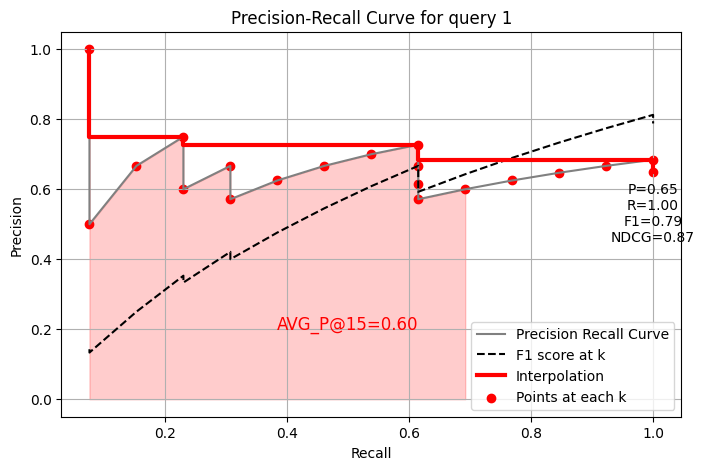

p@15 = 0.600
r@15 = 0.692
ap@15 = 0.600
f1@15 = 0.643
ndcg@15 = 0.695


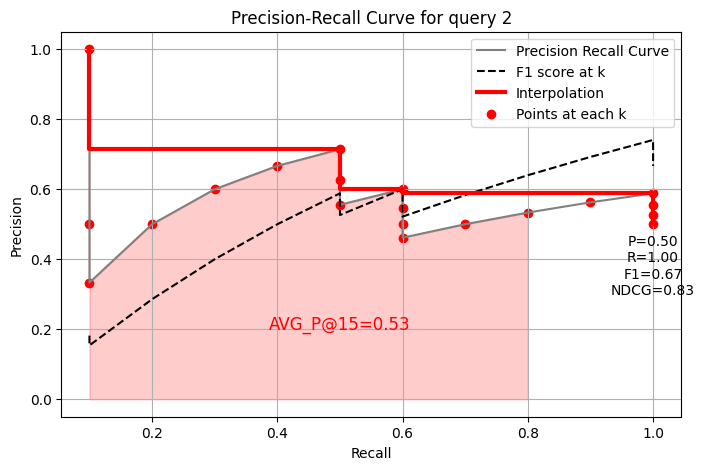

p@15 = 0.533
r@15 = 0.800
ap@15 = 0.533
f1@15 = 0.640
ndcg@15 = 0.727

map@15 = 0.567
mrr@15 = 1.000


In [28]:
print_evaluation(search_results, k=15)

### Evaluate our queries and the ranking results

#### Create the csv with our results labeled as relevant and non-relevant

To evaluate the results, we are gonna create a .csv in the same format as the one it was given to us with the predefined queries to reuse the code above:

In [29]:
results_dict = []

for idx, query in enumerate(queries):

    # Get the scores (ranking)
    scores = engine_search(query, index, tf, idf, weights)

    # We do not check for queries with no results because we already know these queries give a ranking
    for score, pid in scores:
        row = {
            "title": index2title[pid],
            "pid": pid,
            "query_id": idx+1
        }

        results_dict.append(row)

# Create a dataframe of the dict
results_df = pd.DataFrame(results_dict)

# Save dataframe into csv
results_df.to_csv("../../data/results.csv", index=False)

The following code is to print the products in ranking for each query to assess if they are relevant or not. The column `label` in the csv was added manually to csv and then we changed the name for the code to not overwrite it if we executed it again.

In [30]:
query = queries[4]
scores = engine_search(query, index, tf, idf, weights)

print(f"QUERY: '{query}'")
print(f"RANKING:")
for idx, (score, pid) in enumerate(scores):
    print(f"{idx+1:4}. [idf={score:.3f}] {corpus[pid]}")

QUERY: 'breathable sports clothes winter'
RANKING:
   1. [idf=0.883] {
  "pid": "JCKFTZBBWWQAT4HF",
  "title": "Full Sleeve Printed Men Sports Jacket",
  "description": "PRODUCT STORY   Constructed using highly breathable fabrics and form-fitting cuts, this officially licensed training jacket will have you looking as fierce as your favourite footballers. Featuring stylish patchwork panelling and a sporty silhouette, you'll support your team with sleek style.   DETAILS   Combined PUMA Formstrip shoulder and back panel construction  Engineered jacquard integrated into the sleeves for enhanced breathability  Official Borussia Dortmund crest at left chest  Sponsor and PUMA Cat Logos at right chest  100% Polyester",
  "brand": "Pu",
  "category": "Clothing and Accessories",
  "sub_category": "Winter Wear",
  "product_details": {
    "Color": "Black",
    "Fabric": "Polyester",
    "Pattern": "Printed",
    "Style Code": "75770702",
    "Ideal For": "Men",
    "Sleeve": "Full Sleeve",
    "S

#### Our queries' evaluation

In [31]:
our_search_results = pd.read_csv("../../data/results_labeled.csv")
display(our_search_results.head())
print_result = our_search_results["labels"].unique()
print("The ground truth of our dataset is composed of {} Relevance Levels: {}".format(len(print_result), sorted(print_result)))

,title,pid,query_id,labels
0,Full Sleeve Solid Men Leather Jacket,JCKFWZBYVHJGQDGT,1,1
1,Full Sleeve Solid Men Leather Jacket,JCKFWZBYSXCEQDYD,1,1
2,Full Sleeve Solid Men Leather Jacket,JCKFWZBYPATZVGPB,1,1
3,Full Sleeve Solid Men Leather Jacket,JCKFWZBYHDRNMSZF,1,1
4,Full Sleeve Solid Men Leather Jacket,JCKFWZBYFHGWZ6RF,1,1


The ground truth of our dataset is composed of 2 Relevance Levels: [np.int64(0), np.int64(1)]


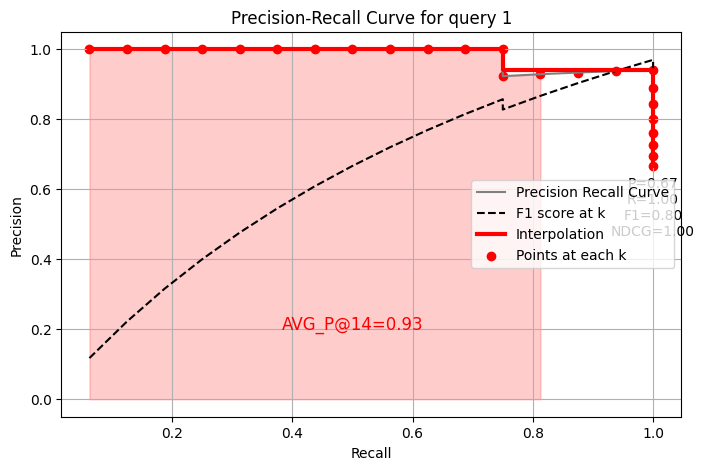

p@14 = 0.929
r@14 = 0.812
ap@14 = 0.929
f1@14 = 0.867
ndcg@14 = 0.953


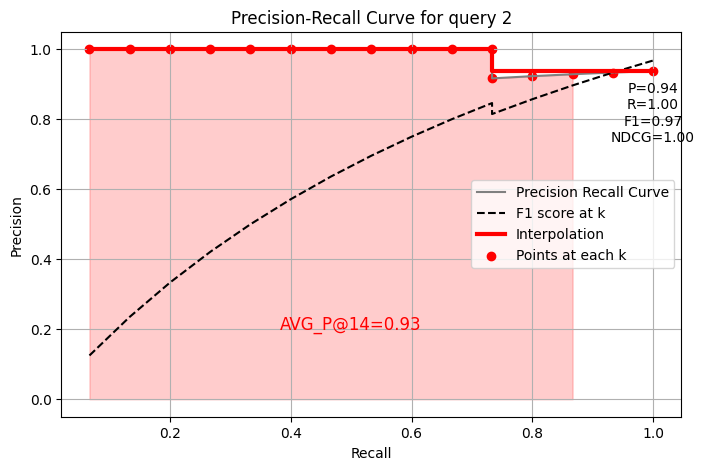

p@14 = 0.929
r@14 = 0.867
ap@14 = 0.929
f1@14 = 0.897
ndcg@14 = 0.952


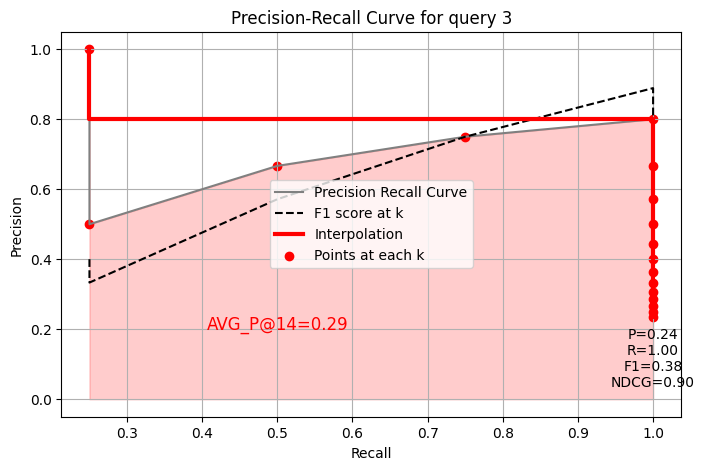

p@14 = 0.286
r@14 = 1.000
ap@14 = 0.286
f1@14 = 0.444
ndcg@14 = 0.905


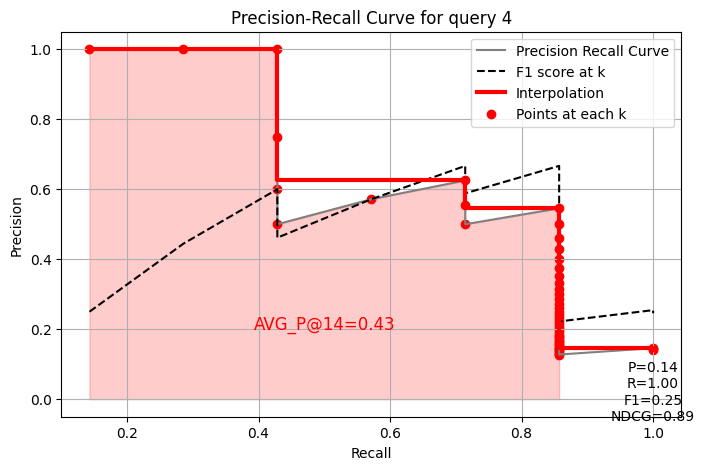

p@14 = 0.429
r@14 = 0.857
ap@14 = 0.429
f1@14 = 0.571
ndcg@14 = 0.841


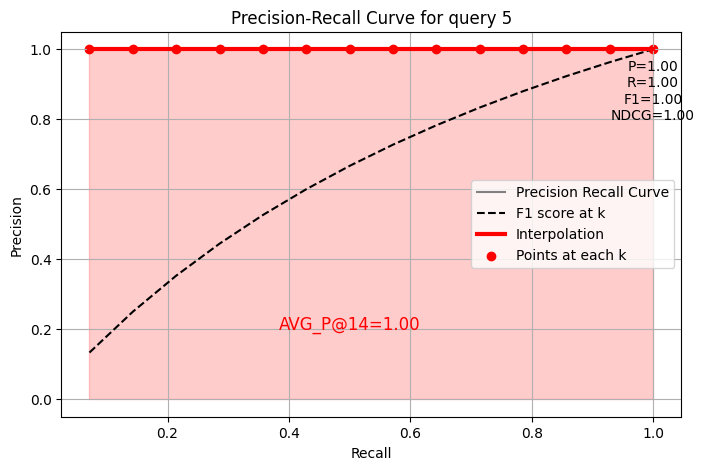

p@14 = 1.000
r@14 = 1.000
ap@14 = 1.000
f1@14 = 1.000
ndcg@14 = 1.000

map@14 = 0.929
mrr@14 = 1.000


In [32]:
print_evaluation(our_search_results, k=14)  # k=14 because it is the largest number of results in all queries